# Customer Churn Prediction using Machine Learning

## Objective
This project predicts whether a telecom customer is likely to churn based on customer demographics, billing information, and subscribed services.

## Why this matters
Customer churn prediction helps telecom companies identify high-risk customers early and improve retention strategies.

In [75]:
# Data Handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# Display settings
pd.set_option("display.max_columns", None)

In [76]:
# 1. Load Dataset
df = pd.read_csv("/content/drive/MyDrive/Customer Churn Prediction/Telcom-Customer-Churn.csv")

In [77]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [78]:
# 2. Data Understanding
df.shape

(7043, 21)

In [79]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [80]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [81]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [82]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [83]:
df.duplicated().sum()

np.int64(0)

In [84]:
# 3. Data Cleaning
df.drop("customerID", axis=1, inplace=True)

In [85]:
df["TotalCharges"].unique()[:10]

array(['29.85', '1889.5', '108.15', '1840.75', '151.65', '820.5',
       '1949.4', '301.9', '3046.05', '3487.95'], dtype=object)

In [86]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

In [87]:
df["TotalCharges"].fillna(
    df["TotalCharges"].median(),
    inplace=True
)

In [88]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [89]:
df.isnull().sum()

,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0
OnlineBackup,0


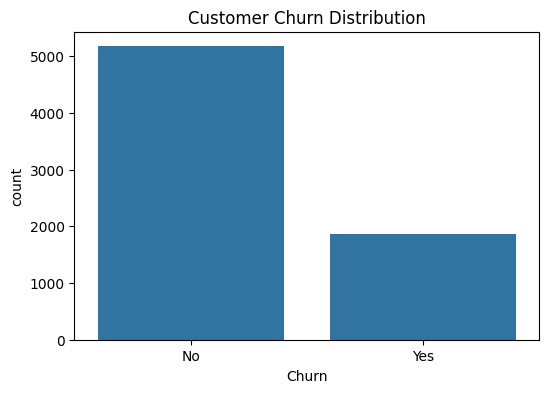

In [90]:
# 4. Exploratory Data Analysis (EDA)

plt.figure(figsize=(6,4))

sns.countplot(
    x="Churn",
    data=df
)

plt.title("Customer Churn Distribution")
plt.show()

In [91]:
df["Churn"].value_counts(normalize=True) * 100

,proportion
Churn,
No,73.463013
Yes,26.536987


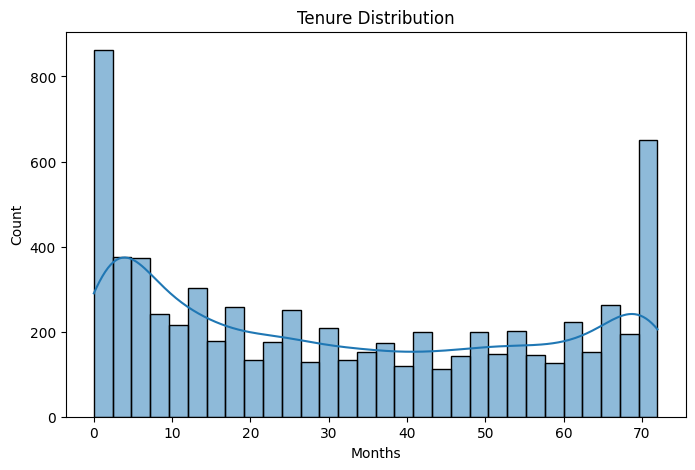

In [92]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["tenure"],
    bins=30,
    kde=True
)

plt.title("Tenure Distribution")
plt.xlabel("Months")
plt.show()

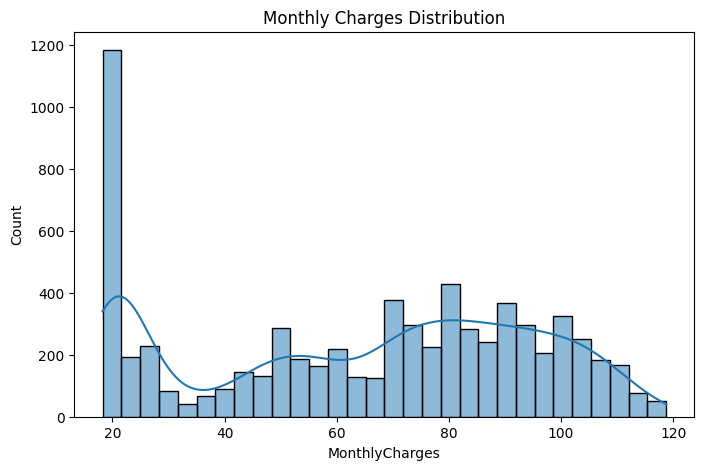

In [93]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["MonthlyCharges"],
    bins=30,
    kde=True
)

plt.title("Monthly Charges Distribution")
plt.show()

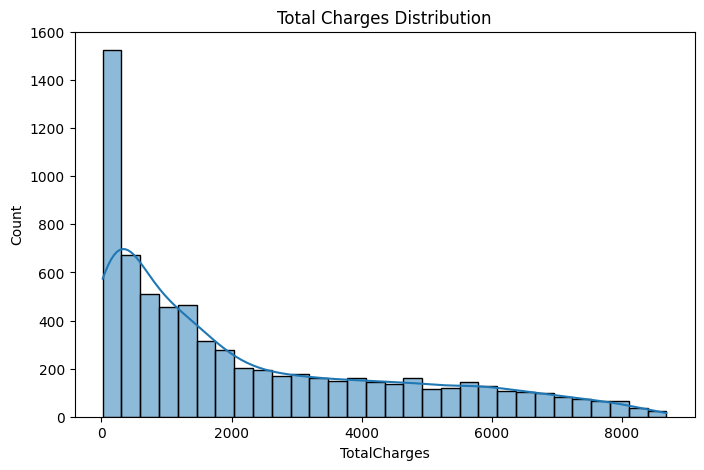

In [94]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["TotalCharges"],
    bins=30,
    kde=True
)

plt.title("Total Charges Distribution")
plt.show()

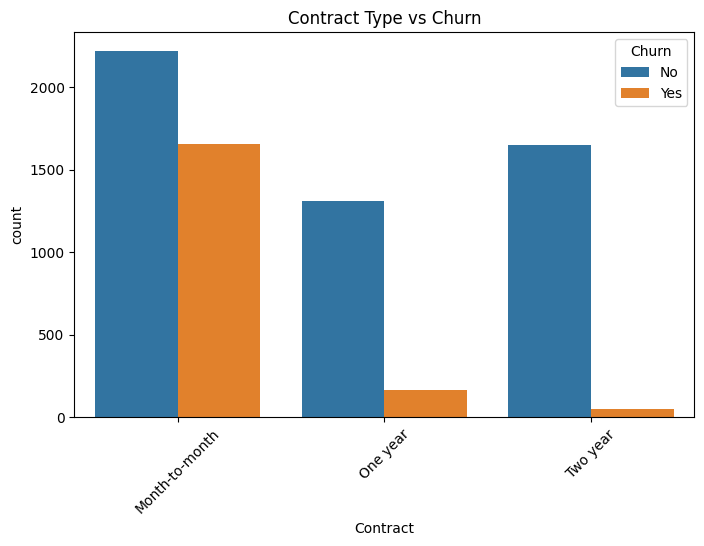

In [95]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="Contract",
    hue="Churn",
    data=df
)

plt.xticks(rotation=45)
plt.title("Contract Type vs Churn")
plt.show()

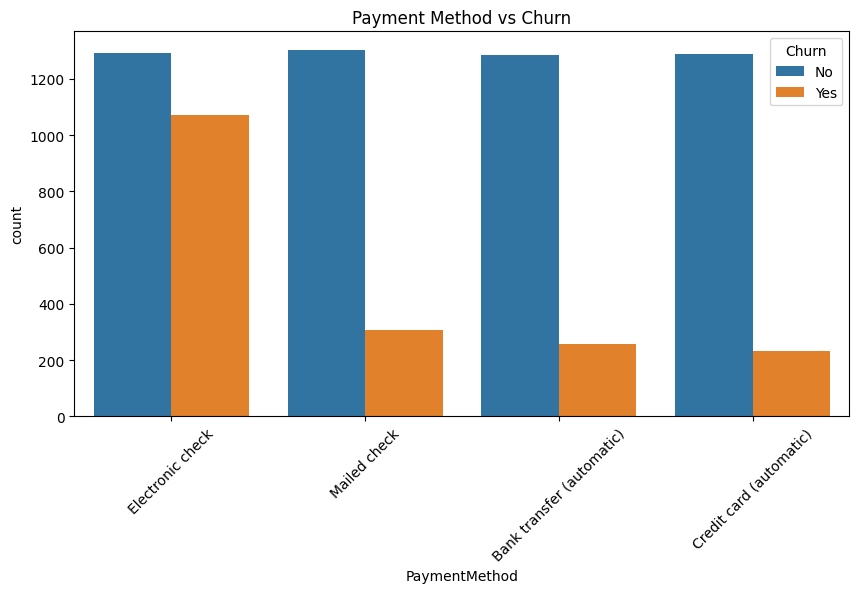

In [96]:
plt.figure(figsize=(10,5))

sns.countplot(
    x="PaymentMethod",
    hue="Churn",
    data=df
)

plt.xticks(rotation=45)
plt.title("Payment Method vs Churn")
plt.show()

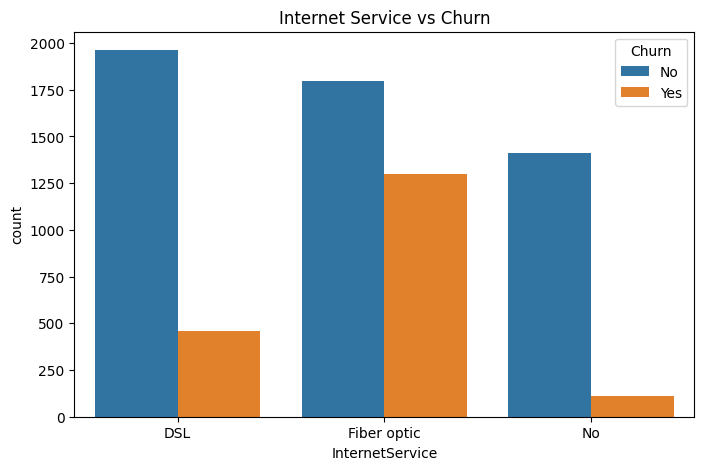

In [97]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="InternetService",
    hue="Churn",
    data=df
)

plt.title("Internet Service vs Churn")
plt.show()

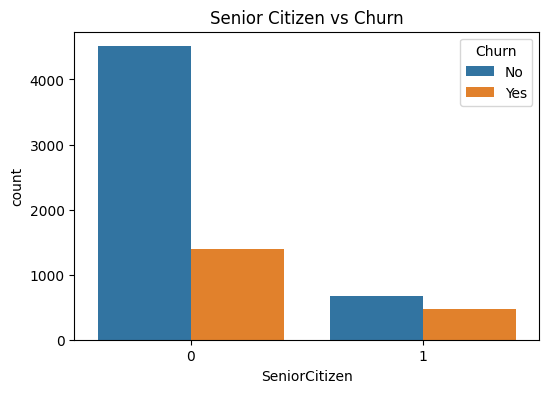

In [98]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="SeniorCitizen",
    hue="Churn",
    data=df
)

plt.title("Senior Citizen vs Churn")
plt.show()

In [99]:
numeric_df = df.select_dtypes(
    include=["int64", "float64"]
)

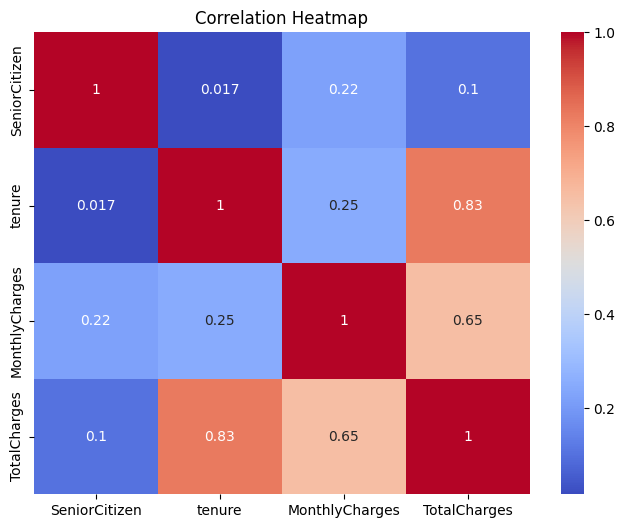

In [100]:
plt.figure(figsize=(8,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

# Initial Business Insights

### Key observations:
- Month-to-month contract customers appear to churn more.
- Short-tenure customers are at higher churn risk.
- Higher monthly charges may correlate with churn.
- Churn data is imbalanced, which justifies SMOTE later.

In [101]:
df["Churn"] = df["Churn"].map({
    "Yes": 1,
    "No": 0
})

In [102]:
df["Churn"].value_counts()

,count
Churn,
0,5174
1,1869


# One-Hot Encoding

Categorical columns are converted into machine-readable binary columns.


In [103]:
df = pd.get_dummies(
    df,
    drop_first=True
)

In [104]:
df.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,True,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,True,False,False,True,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,True,False,False,False,True,False,False,False,False,True,False,False,False,True,False,True,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False


In [105]:
df.shape


(7043, 31)

In [106]:
# 6. Split Features and Target
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [107]:
feature_columns = X.columns.tolist()

In [108]:
X.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,False,True,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,True,False,False,True,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,True,False,False,True,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,True,False,False,False,True,False,False,False,False,True,False,False,False,True,False,True,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False


In [109]:
# 7. Train Test Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [110]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (5634, 30)
X_test : (1409, 30)
y_train: (5634,)
y_test : (1409,)


# Feature Scaling


In [111]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(
    X_train
)

X_test_scaled = scaler.transform(
    X_test
)
X_train_scaled.shape

(5634, 30)

# SMOTE (Synthetic Minority Oversampling)

The churn dataset is imbalanced.

Balance minority class using SMOTE.

In [112]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(
    random_state=42
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)
y_train_smote.value_counts()

,count
Churn,
0,4139
1,4139


# Model Training


Models:
- Decision Tree
- Random Forest
- XGBoost

In [113]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [114]:
dt = DecisionTreeClassifier(
    random_state=42
)

dt.fit(
    X_train_smote,
    y_train_smote
)

DecisionTreeClassifier(random_state=42)

In [115]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(
    X_train_smote,
    y_train_smote
)

RandomForestClassifier(random_state=42)

In [116]:
xgb = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

xgb.fit(
    X_train_smote,
    y_train_smote
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

# Quick Test Accuracy Comparison

In [117]:
dt_acc = dt.score(
    X_test_scaled,
    y_test
)

print("Decision Tree Accuracy:", dt_acc)

Decision Tree Accuracy: 0.723207948899929


In [118]:
rf_acc = rf.score(
    X_test_scaled,
    y_test
)

print("Random Forest Accuracy:", rf_acc)

Random Forest Accuracy: 0.7721788502484032


In [119]:
xgb_acc = xgb.score(
    X_test_scaled,
    y_test
)

print("XGBoost Accuracy:", xgb_acc)

XGBoost Accuracy: 0.7672107877927609


# Final Model Selection

Random Forest is selected as the final production model
because it provides strong performance and stability.
# Cross Validation


In [120]:
from sklearn.model_selection import cross_val_score

In [121]:
cv_scores = cross_val_score(
    rf,
    X_train_smote,
    y_train_smote,
    cv=5
)

In [122]:
print("Cross Validation Scores:")
print(cv_scores)

print("\nMean CV Score:")
print(cv_scores.mean())

Cross Validation Scores:
[0.79589372 0.80072464 0.90640097 0.89244713 0.88096677]

Mean CV Score:
0.8552866441904928


# Training Summary

Completed:
- Feature engineering
- One-hot encoding
- Train/Test split
- Scaling
- SMOTE
- Model training
- Model comparison
- Cross validation


# Model Evaluation

Now we evaluate the final selected model (Random Forest).

In [123]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

In [124]:
y_pred = rf.predict(X_test_scaled)

In [125]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy Score:", accuracy)

Accuracy Score: 0.7721788502484032


In [126]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.85      0.84      0.84      1035
           1       0.57      0.59      0.58       374

    accuracy                           0.77      1409
   macro avg       0.71      0.72      0.71      1409
weighted avg       0.78      0.77      0.77      1409



In [127]:
cm = confusion_matrix(
    y_test,
    y_pred
)

cm

array([[866, 169],
       [152, 222]])

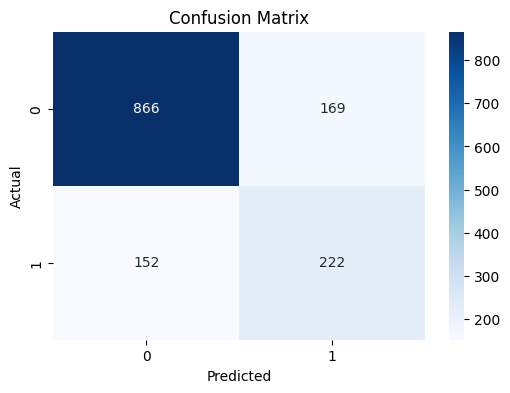

In [128]:
plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [129]:
y_prob = rf.predict_proba(
    X_test_scaled
)[:, 1]

roc_auc = roc_auc_score(
    y_test,
    y_prob
)

print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 0.8236366219742179


# Feature Importance

We identify which features influence churn most.

In [130]:
importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
)

In [131]:
importance.sort_values(
    ascending=False
).head(10)

,0
tenure,0.155043
TotalCharges,0.134710
MonthlyCharges,0.128622
Contract_Two year,0.064356
PaymentMethod_Electronic check,0.049559
InternetService_Fiber optic,0.044384
OnlineSecurity_Yes,0.041219
PaperlessBilling_Yes,0.036136
Contract_One year,0.035296
TechSupport_Yes,0.031196


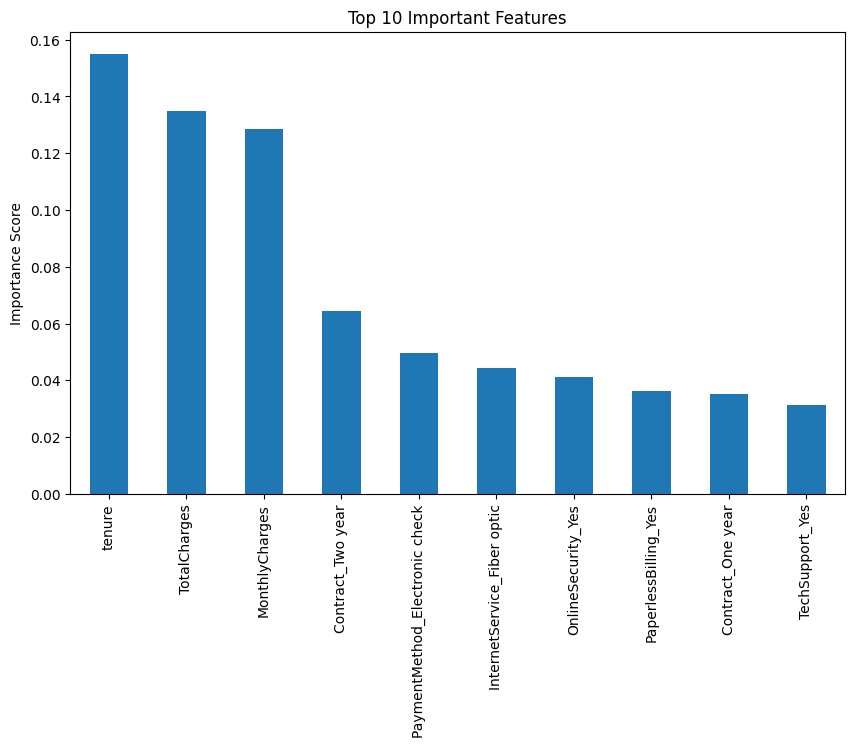

In [132]:
plt.figure(figsize=(10,6))

importance.sort_values(
    ascending=False
).head(10).plot(
    kind="bar"
)

plt.title("Top 10 Important Features")
plt.ylabel("Importance Score")
plt.show()

#Save Deployment Files

We save:
- model.pkl
- scaler.pkl
- columns.pkl

In [133]:
import joblib

In [134]:
joblib.dump(
    rf,
    "model.pkl"
)

['model.pkl']

In [135]:
joblib.dump(
    scaler,
    "scaler.pkl"
)

['scaler.pkl']

In [136]:
joblib.dump(
    feature_columns,
    "columns.pkl"
)

['columns.pkl']

In [137]:
# Load Model Again

loaded_model = joblib.load(
    "model.pkl"
)

loaded_scaler = joblib.load(
    "scaler.pkl"
)

loaded_columns = joblib.load(
    "columns.pkl"
)

In [138]:
type(loaded_model)

sklearn.ensemble._forest.RandomForestClassifier

# Predict New Customer Churn

In [139]:
input_data = {
    'gender': 'Female',
    'SeniorCitizen': 0,
    'Partner': 'Yes',
    'Dependents': 'No',
    'tenure': 1,
    'PhoneService': 'No',
    'MultipleLines': 'No phone service',
    'InternetService': 'DSL',
    'OnlineSecurity': 'No',
    'OnlineBackup': 'Yes',
    'DeviceProtection': 'No',
    'TechSupport': 'No',
    'StreamingTV': 'No',
    'StreamingMovies': 'No',
    'Contract': 'Month-to-month',
    'PaperlessBilling': 'Yes',
    'PaymentMethod': 'Electronic check',
    'MonthlyCharges': 29.85,
    'TotalCharges': 29.85
}

In [140]:
input_df = pd.DataFrame(
    [input_data]
)
input_df = pd.get_dummies(
    input_df,
    drop_first=True
)

In [141]:
input_df = input_df.reindex(
    columns=loaded_columns,
    fill_value=0
)

In [142]:
scaled_input = loaded_scaler.transform(
    input_df
)

In [143]:
prediction = loaded_model.predict(
    scaled_input
)

pred_prob = loaded_model.predict_proba(
    scaled_input
)
print(prediction)
print(pred_prob)

[0]
[[0.6 0.4]]


In [144]:
print(
    f"Prediction: "
    f"{'Churn' if prediction[0] == 1 else 'No Churn'}"
)

print(
    f"Churn Probability: "
    f"{pred_prob[0][1]:.2%}"
)

Prediction: No Churn
Churn Probability: 40.00%


# Final Conclusion

Random Forest performed best for telecom customer churn prediction.

## Key Findings
- Contract type strongly affects churn.
- Short-tenure customers are high risk.
- Monthly charges influence churn probability.
- SMOTE improved minority class learning.
- Feature importance helped identify business drivers.
